In [1]:
# 1. Imports and Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob
import random

In [2]:
# Check for GPU availability and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# 2. Parameters
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 1
# Note: In PyTorch, buffer_size is handled by DataLoader's shuffle mechanism
# BUFFER_SIZE = 1000
LAMBDA_CYCLE = 10
LAMBDA_IDENTITY = 5 # Corresponds to LAMBDA * 0.5 in the original code

# Define paths to the datasets
CELEBA_PATH = 'data/trainA'
VAN_GOGH_PATH = 'data/trainB'

In [4]:
# 3. Data Loading and Preprocessing
class ImageDataset(Dataset):
    """Custom PyTorch dataset for loading images from a directory."""
    def __init__(self, root, transform=None):
        self.transform = transform
        self.files = sorted(glob.glob(os.path.join(root, "*.jpg")))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        img = Image.open(self.files[index % len(self.files)]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Define image transformations
# ToTensor() scales images to [0, 1].
# Normalize maps them from [0, 1] to [-1, 1].
# Define image transformations with data augmentation
transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE[0] * 1.12), Image.BICUBIC), # Resize to slightly larger
    transforms.RandomCrop(IMAGE_SIZE), # Crop back to original size
    transforms.RandomHorizontalFlip(), # Randomly flip images
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

In [5]:
# Create datasets and dataloaders
celeba_dataset = ImageDataset(CELEBA_PATH, transform=transform)
van_gogh_dataset = ImageDataset(VAN_GOGH_PATH, transform=transform)

# Use drop_last=True to ensure all batches have the same size, which can be
# important for some model architectures, although not strictly necessary here.
celeba_loader = DataLoader(celeba_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
van_gogh_loader = DataLoader(van_gogh_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)


# ... after creating the datasets and dataloaders
print(f"Found {len(celeba_dataset)} images in CelebA folder.")
print(f"Found {len(van_gogh_dataset)} images in Van Gogh folder.")

Found 5000 images in CelebA folder.
Found 281 images in Van Gogh folder.


In [6]:
# 4. Model Architecture
class UNetGenerator(nn.Module):
    """A U-Net based generator with skip connections."""
    def __init__(self, in_channels=3, out_channels=3):
        super(UNetGenerator, self).__init__()

        # Helper functions for blocks
        def down_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, stride=2, padding=1, bias=False)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        def up_block(in_feat, out_feat, dropout=False):
            layers = [nn.ConvTranspose2d(in_feat, out_feat, 4, stride=2, padding=1, bias=False),
                      nn.InstanceNorm2d(out_feat),
                      nn.ReLU(inplace=True)]
            if dropout:
                layers.append(nn.Dropout(0.5))
            return nn.Sequential(*layers)

        # Encoder (Downsampling)
        self.down1 = down_block(in_channels, 64, normalize=False) # 64 -> 32
        self.down2 = down_block(64, 128)                      # 32 -> 16
        self.down3 = down_block(128, 256)                     # 16 -> 8
        self.down4 = down_block(256, 512)                     # 8 -> 4
        # --- THIS IS THE FIX ---
        self.down5 = down_block(512, 512)                     # 4 -> 2 (bottleneck)
        # -----------------------

        # Decoder (Upsampling) with skip connections
        self.up1 = up_block(512, 512, dropout=True) # Takes output from down5
        self.up2 = up_block(1024, 256)              # 512(up) + 512(skip from d4) = 1024
        self.up3 = up_block(512, 128)               # 256(up) + 256(skip from d3) = 512
        self.up4 = up_block(256, 64)                # 128(up) + 128(skip from d2) = 256

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, stride=2, padding=1), # 64(up) + 64(skip from d1) = 128
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder path
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)

        # Decoder path with skip connections
        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], 1))
        u3 = self.up3(torch.cat([u2, d3], 1))
        u4 = self.up4(torch.cat([u3, d2], 1))
        
        return self.final_up(torch.cat([u4, d1], 1))
    

class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super(Discriminator, self).__init__()
        def discriminator_block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, kernel_size=4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        # For 64x64 input, the PatchGAN output is 4x4
        # 64 -> 32 -> 16 -> 8 -> 4
        self.model = nn.Sequential(
            *discriminator_block(input_channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, kernel_size=4, padding=1)
        )

    def forward(self, img):
        return self.model(img)

# 5. Initialization and Loss Functions

gen_G = UNetGenerator().to(device)
gen_F = UNetGenerator().to(device)
disc_X = Discriminator().to(device)
disc_Y = Discriminator().to(device)

In [7]:
def weights_init(m):
    """Applies initial weights to all layers of a network."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm2d') != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

class ReplayBuffer:
    """
    A buffer to store and sample from previously generated images.
    This helps stabilize discriminator training.
    """
    def __init__(self, max_size=50):
        assert max_size > 0, "Empty buffer."
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    i = random.randint(0, self.max_size - 1)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    to_return.append(element)
        return torch.cat(to_return)

In [8]:
# --- Apply Weight Initialization ---
gen_G.apply(weights_init)
gen_F.apply(weights_init)
disc_X.apply(weights_init)
disc_Y.apply(weights_init)
print("Model weights initialized.")

# --- Create Replay Buffers ---
fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()
print("Replay buffers created.")

# --- Loss functions ---
adversarial_loss = nn.BCEWithLogitsLoss()
cycle_loss = nn.L1Loss()
identity_loss = nn.L1Loss()

# --- Optimizers ---
optimizer_G = optim.Adam(
    list(gen_G.parameters()) + list(gen_F.parameters()), lr=0.0002, betas=(0.5, 0.999)
)
optimizer_D_X = optim.Adam(disc_X.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_Y = optim.Adam(disc_Y.parameters(), lr=0.0002, betas=(0.5, 0.999))

# --- Learning Rate Schedulers ---
EPOCHS = 100
DECAY_START_EPOCH = 50

lr_lambda = lambda epoch: 1.0 - max(0, epoch + 1 - DECAY_START_EPOCH) / float(EPOCHS - DECAY_START_EPOCH + 1)
scheduler_G = optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lr_lambda)
scheduler_D_X = optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lr_lambda)
scheduler_D_Y = optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lr_lambda)

Model weights initialized.
Replay buffers created.


In [9]:
# Lists to store loss history for plotting
gen_loss_history = []
disc_loss_history = []

print("Starting Training Loop...")
for epoch in range(EPOCHS):
    for i, (real_x, real_y) in enumerate(zip(celeba_loader, van_gogh_loader)):
        real_x, real_y = real_x.to(device), real_y.to(device)
        patch_size = (1, 4, 4)
        target_real = torch.ones(real_x.size(0), *patch_size, device=device)
        target_fake = torch.zeros(real_x.size(0), *patch_size, device=device)

        # --- Train Generators ---
        gen_G.train()
        gen_F.train()
        optimizer_G.zero_grad()
        loss_id_x = identity_loss(gen_F(real_x), real_x)
        loss_id_y = identity_loss(gen_G(real_y), real_y)
        loss_identity = (loss_id_x + loss_id_y) / 2
        fake_y = gen_G(real_x)
        loss_adv_g = adversarial_loss(disc_Y(fake_y), target_real)
        fake_x = gen_F(real_y)
        loss_adv_f = adversarial_loss(disc_X(fake_x), target_real)
        loss_adversarial = (loss_adv_g + loss_adv_f) / 2
        cycled_x = gen_F(fake_y)
        loss_cycle_x = cycle_loss(cycled_x, real_x)
        cycled_y = gen_G(fake_x)
        loss_cycle_y = cycle_loss(cycled_y, real_y)
        loss_cycle = (loss_cycle_x + loss_cycle_y) / 2
        loss_G = loss_adversarial + LAMBDA_CYCLE * loss_cycle + LAMBDA_IDENTITY * loss_identity
        loss_G.backward()
        optimizer_G.step()

        # --- Train Discriminator X (for CelebA) using Replay Buffer ---
        optimizer_D_X.zero_grad()
        loss_real = adversarial_loss(disc_X(real_x), target_real)
        fake_x_ = fake_A_buffer.push_and_pop(fake_x)
        loss_fake = adversarial_loss(disc_X(fake_x_.detach()), target_fake)
        loss_D_X = (loss_real + loss_fake) / 2
        loss_D_X.backward()
        optimizer_D_X.step()

        # --- Train Discriminator Y (for Van Gogh) using Replay Buffer ---
        optimizer_D_Y.zero_grad()
        loss_real = adversarial_loss(disc_Y(real_y), target_real)
        fake_y_ = fake_B_buffer.push_and_pop(fake_y)
        loss_fake = adversarial_loss(disc_Y(fake_y_.detach()), target_fake)
        loss_D_Y = (loss_real + loss_fake) / 2
        loss_D_Y.backward()
        optimizer_D_Y.step()

    # Store last batch losses for this epoch
    total_loss_D = (loss_D_X + loss_D_Y) / 2
    gen_loss_history.append(loss_G.item())
    disc_loss_history.append(total_loss_D.item())
    scheduler_G.step()
    scheduler_D_X.step()
    scheduler_D_Y.step()
    
    print(
        f"[Epoch {epoch+1}/{EPOCHS}] [D loss: {total_loss_D.item():.4f}] [G loss: {loss_G.item():.4f}]"
    )

Starting Training Loop...
[Epoch 1/100] [D loss: 0.6833] [G loss: 3.1872]
[Epoch 2/100] [D loss: 0.7062] [G loss: 3.9645]
[Epoch 3/100] [D loss: 0.8667] [G loss: 2.2404]
[Epoch 4/100] [D loss: 0.4153] [G loss: 2.5777]
[Epoch 5/100] [D loss: 0.6021] [G loss: 3.2934]
[Epoch 6/100] [D loss: 0.8293] [G loss: 2.8544]
[Epoch 7/100] [D loss: 0.4329] [G loss: 3.3139]
[Epoch 8/100] [D loss: 0.6418] [G loss: 2.3928]
[Epoch 9/100] [D loss: 0.2947] [G loss: 2.6105]
[Epoch 10/100] [D loss: 0.8026] [G loss: 2.7099]
[Epoch 11/100] [D loss: 0.6195] [G loss: 2.3089]
[Epoch 12/100] [D loss: 1.7155] [G loss: 1.9225]
[Epoch 13/100] [D loss: 0.9460] [G loss: 2.4246]
[Epoch 14/100] [D loss: 0.6879] [G loss: 2.3158]
[Epoch 15/100] [D loss: 0.4967] [G loss: 2.9423]
[Epoch 16/100] [D loss: 0.4867] [G loss: 2.9946]
[Epoch 17/100] [D loss: 0.7714] [G loss: 3.5315]
[Epoch 18/100] [D loss: 0.3072] [G loss: 4.0301]
[Epoch 19/100] [D loss: 0.5638] [G loss: 2.1542]
[Epoch 20/100] [D loss: 1.0689] [G loss: 2.5653]
[Ep

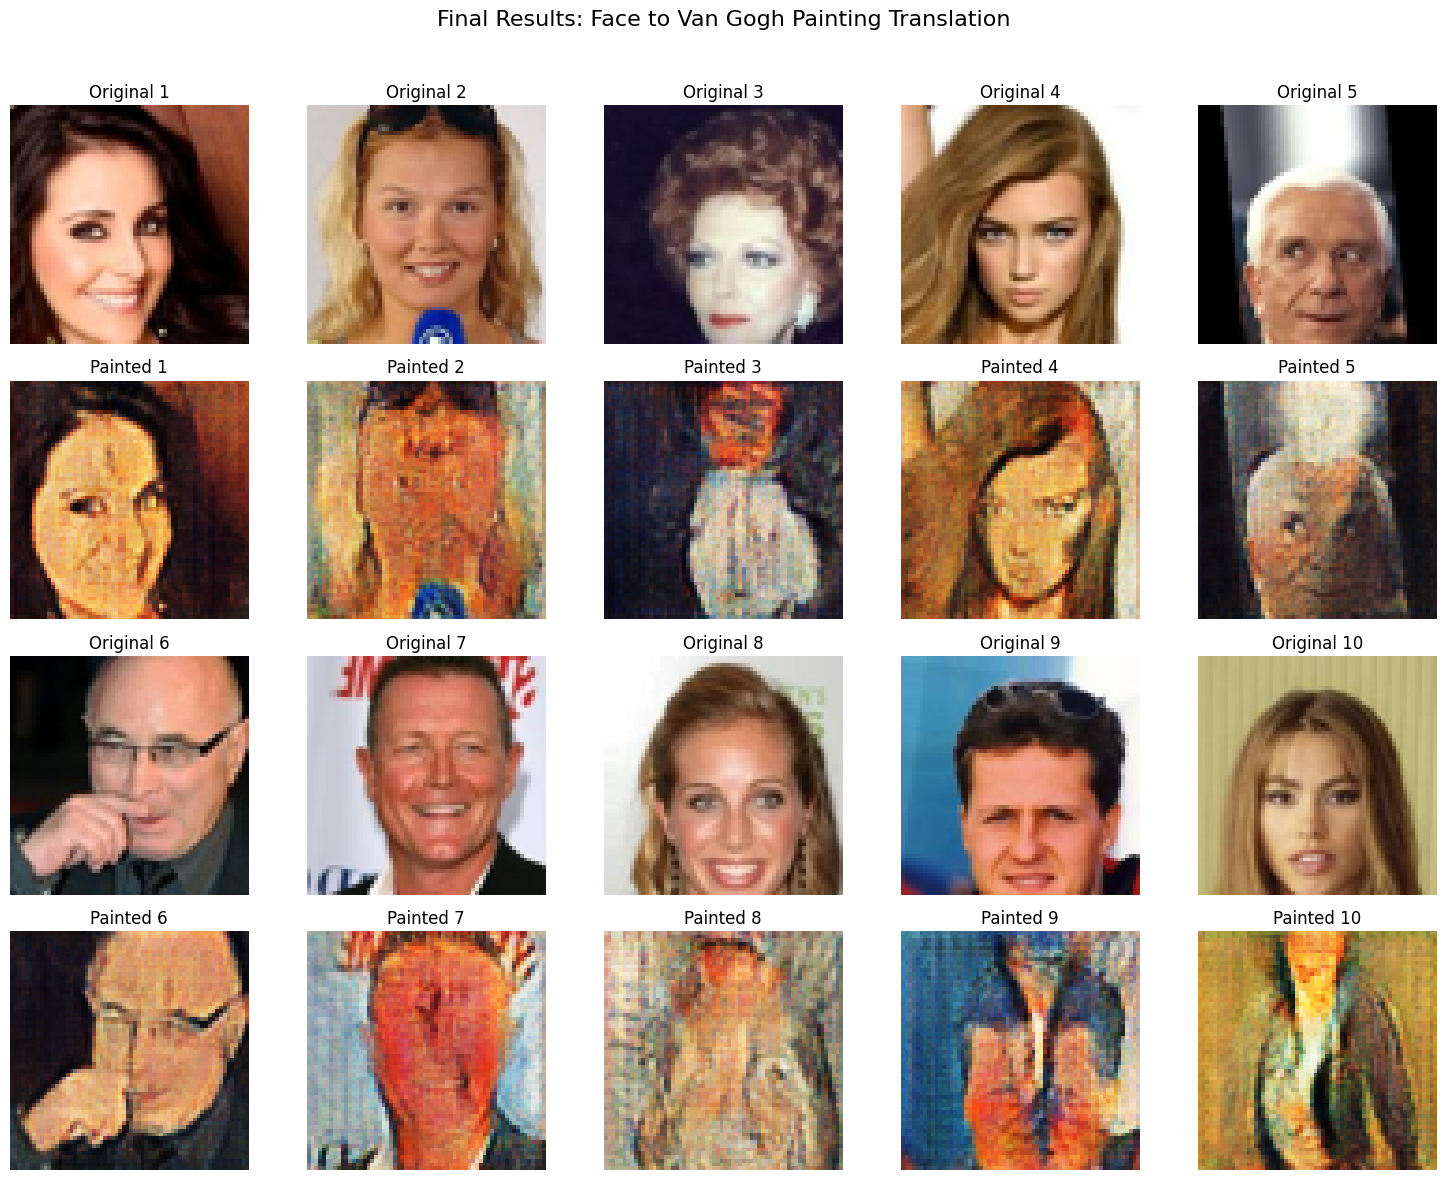

In [10]:
# 7. Plotting Results
def unnormalize(img_tensor):
    img_np = img_tensor.detach().cpu().numpy()
    img_np = np.transpose(img_np, (1, 2, 0))
    return (img_np * 0.5) + 0.5

# --- Plot Final Generated Images (4x5 grid showing 10 pairs) ---
num_image_pairs = 10
num_rows = 4
num_cols = 5
plt.figure(figsize=(15, 12))
plt.suptitle("Final Results: Face to Van Gogh Painting Translation", fontsize=16)

gen_G.eval()

with torch.no_grad():
    image_pairs = []
    # Get 10 sample images
    for i, real_x in enumerate(celeba_loader):
        if i >= num_image_pairs:
            break
        image_pairs.append(real_x)
    
    # Plot the 10 pairs
    for i in range(num_image_pairs):
        real_img = image_pairs[i].to(device)
        pred_img = gen_G(real_img)
        
        # Determine current row and column for subplot
        row_idx = (i // num_cols) * 2 
        col_idx = i % num_cols

        # Plot original image
        plt.subplot(num_rows, num_cols, row_idx * num_cols + col_idx + 1)
        plt.title(f"Original {i+1}")
        plt.imshow(unnormalize(real_img.squeeze(0)))
        plt.axis('off')

        # Plot translated image on the row below
        plt.subplot(num_rows, num_cols, (row_idx + 1) * num_cols + col_idx + 1)
        plt.title(f"Painted {i+1}")
        plt.imshow(unnormalize(pred_img.squeeze(0)))
        plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

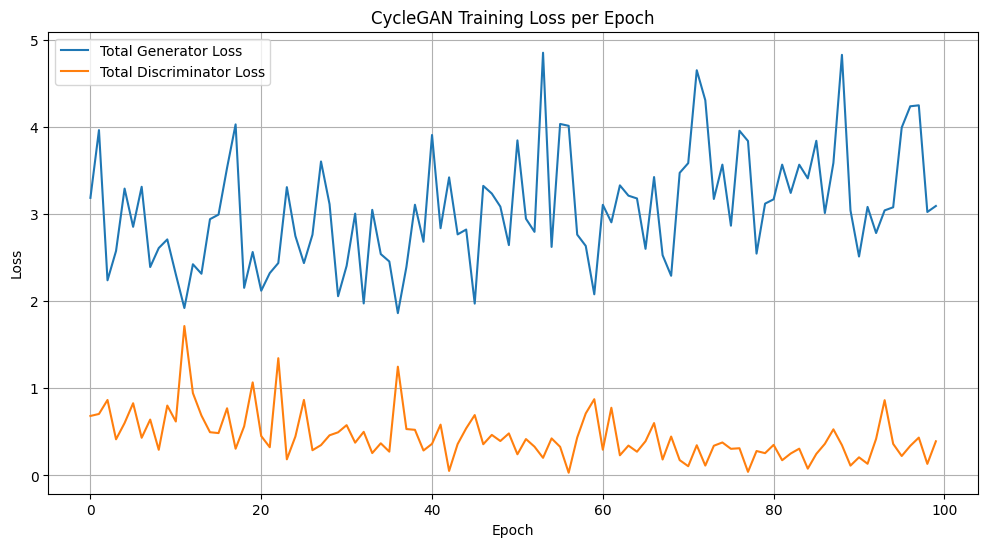

In [11]:
# --- Plot Training Loss ---
plt.figure(figsize=(12, 6))
plt.plot(gen_loss_history, label='Total Generator Loss')
plt.plot(disc_loss_history, label='Total Discriminator Loss')
plt.title("CycleGAN Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()